In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings('ignore')

from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles
import astropy.units as u
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}

In [2]:
df = pd.read_csv('log-results-eDR3-MF_integrada.csv', index_col = 'Cluster')
data = pd.read_csv('data.csv', index_col ='Cluster')

In [4]:
df.FeH.describe()

count    771.000000
mean      -0.035634
std        0.107249
min       -0.373000
25%       -0.113500
50%       -0.036000
75%        0.032000
max        0.426000
Name: FeH, dtype: float64

In [3]:
aux = data.copy(deep=True)

In [4]:
def classificar_metalicidade(m):
    if m < -0:
        return '[Fe/H]<0'
    else:
        return '[Fe/H]>0'

# Aplicar a função e criar/atualizar coluna
aux['FeH_class'] = aux['FeH'].apply(classificar_metalicidade)
df['FeH_class'] = df['FeH'].apply(classificar_metalicidade)

In [5]:
aux  = aux[aux.q>0]

In [6]:
aux['FeH_class'].value_counts()

FeH_class
[Fe/H]<0    54321
[Fe/H]>0    32233
Name: count, dtype: int64

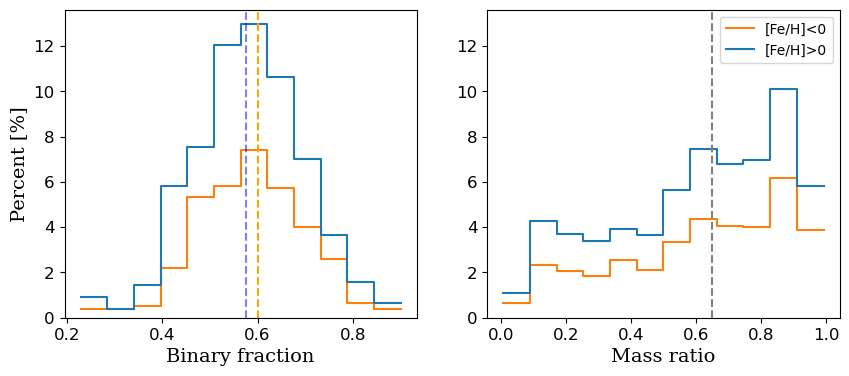

In [9]:
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)


sns.histplot(data=df, x='bin_frac', hue='FeH_class', bins=12,
                   element='step', fill=None, stat='percent', legend=False, ax=axs[0], hue_order=['[Fe/H]<0', '[Fe/H]>0'])

axs[0].axvline(df[df.FeH<-0.1].bin_frac.median(), color='orange', linestyle='--')
axs[0].axvline(df[df.FeH>=-0.1].bin_frac.median(), color='b', linestyle='--', alpha=0.5)

sns.histplot(data=aux, x='q', hue='FeH_class', bins=12, hue_order=['[Fe/H]<0', '[Fe/H]>0'],
                   element='step', fill=None, stat='percent', legend=False, ax=axs[1])

axs[1].axvline(aux[aux.FeH<-0.1].q.median(), color='gray', linestyle='--')


axs[0].set_xlabel('Binary fraction', fontdict=font)
axs[1].set_xlabel('Mass ratio', fontdict=font)
axs[0].set_ylabel('Percent [%]', fontdict=font)
axs[1].legend(title='', labels=['[Fe/H]<0', '[Fe/H]>0']) 
axs[0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
plt.savefig('hist_mass_ratio_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
def classificar_metalicidade(d):
    if d < 1:
        return 'Near clusters'
    else:
        return 'Distant clusters'

# Aplicar a função e criar/atualizar coluna
df['dist_class'] = df['dist'].apply(classificar_metalicidade)


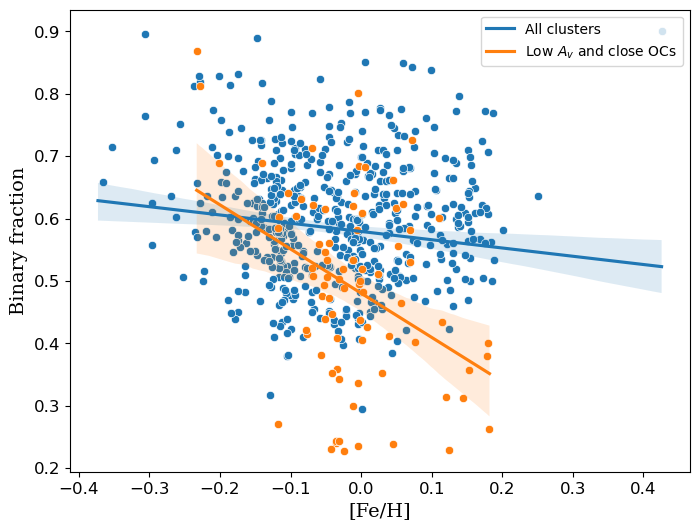

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df[(df.dist>=1)], x='FeH', y= 'bin_frac',)
sns.regplot(data=df, x='FeH', y='bin_frac',
            scatter=False, label='All clusters', color='tab:blue',)


sns.scatterplot(data=df[(df.dist<1) & (df.Av<.5)], x='FeH', y= 'bin_frac',)
sns.regplot(data=df[(df.dist<1) & (df.Av<.5)], x='FeH', y='bin_frac', label =r'Low $A_v$ and close OCs', scatter=False, color='tab:orange')


plt.xlabel('[Fe/H]', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.legend()
plt.tick_params(labelleft=True, labelbottom=True, labelsize=12)
plt.savefig('dist_fb_metalicidade.png',bbox_inches='tight', dpi=300)
plt.show()



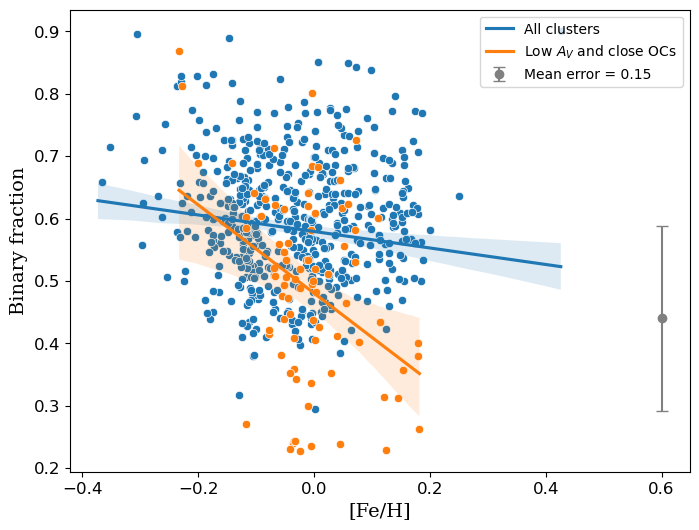

In [17]:
plt.figure(figsize=(8, 6))

# Subamostras
all_clusters = df[df['dist'] >= 1]
low_Av_close = df[(df['dist'] < 1) & (df['Av'] < 0.5)]

# Scatter e regressão para amostra geral
sns.scatterplot(data=all_clusters, x='FeH', y='bin_frac')
sns.regplot(data=df, x='FeH', y='bin_frac',
            scatter=False, label='All clusters', color='tab:blue')

# Scatter e regressão para subamostra
sns.scatterplot(data=low_Av_close, x='FeH', y='bin_frac')
sns.regplot(data=low_Av_close, x='FeH', y='bin_frac',
            scatter=False, label=r'Low $A_V$ and close OCs', color='tab:orange')

# Cálculo da barra de erro média (pode ajustar para a subamostra também)
mean_err = df['er_bin_frac'].median()  # ou df['bin_frac'].sem()
mean_feh = df['FeH'].mean()
mean_fb = df['bin_frac'].mean()

# Adiciona a barra de erro no canto superior direito do gráfico
plt.errorbar(x=0.6, y=0.44, yerr=mean_err, fmt='o', color='gray',
             label=f'Mean error = {mean_err:.2f}', capsize=4)

# Eixos e legendas
plt.xlabel('[Fe/H]', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.legend()
plt.tick_params(labelleft=True, labelbottom=True, labelsize=12)

#plt.savefig('dist_fb_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()


In [16]:
df.er_bin_frac.median()

0.1478533066221173

In [288]:
df[(df.dist<1) & (df.Av<.5)][['FeH', 'bin_frac']]

,FeH,bin_frac
Cluster,,
ASCC_113,0.001,0.405303
ASCC_16,0.180,0.400419
ASCC_21,-0.118,0.270440
ASCC_23,-0.069,0.521212
ASCC_29,-0.077,0.414634
...,...,...
UPK_640,0.145,0.312941
UPK_654,-0.048,0.505618
UPK_82,-0.051,0.615385


In [32]:
df[(df.FeH<0) & (df.Av<0.5) & (df.dist<1)].bin_frac.median()

0.5056179775280899

In [33]:
df[(df.FeH>=0) & (df.Av<0.5) & (df.dist<1)].bin_frac.median()

0.44938273548956

In [300]:
69/58

1.1896551724137931

In [262]:
aux[aux.FeH<0].q.median()

0.6433350092772634

In [241]:
df

,RA_ICRS,DE_ICRS,dist,e_dist,age,e_age,FeH,e_FeH,Av,e_Av,...,str_average_ratio,segr_ratio,segr_ratio_std,mass_seg,mass_seg_pval,n_members,e_fb,dist_class,e_fb_s,e_fb_i
Cluster,,,,,,,,,,,,,,,,,,,,,
ASCC_10,51.9055,35.0110,0.642,0.003,8.292,0.088,0.004,0.028,0.793,0.068,...,0.26538,1.53993,6.46874,0.34689,0.00332,159.0,0.078351,Near clusters,0.078351,0.078351
ASCC_105,295.5766,27.4244,0.552,0.002,8.117,0.053,-0.252,0.066,0.765,0.006,...,0.21848,1.12542,5.59048,0.21638,0.05084,323.0,0.087948,Near clusters,0.087948,0.087948
ASCC_107,297.1882,21.9844,0.847,0.008,7.652,0.359,0.253,0.187,1.463,0.204,...,0.22252,1.30286,3.00649,0.37446,0.00101,194.0,0.115084,Near clusters,0.115084,0.115084
ASCC_108,298.4716,39.2269,1.157,0.003,8.241,0.071,-0.097,0.033,0.655,0.050,...,0.24218,1.04515,14.36767,0.11909,0.03634,894.0,0.038893,Distant clusters,0.038893,0.038893
ASCC_11,53.0538,44.8967,0.826,0.005,8.443,0.194,-0.121,0.044,0.975,0.101,...,0.23087,1.26139,7.17919,0.13528,0.11318,493.0,0.047287,Near clusters,0.047287,0.047287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UPK_93,300.1772,30.0312,0.637,0.040,8.766,0.092,-0.228,0.043,0.410,0.097,...,0.22171,1.18673,4.05038,0.29273,0.04022,174.0,0.123855,Near clusters,0.123855,0.123855
UPK_94,304.7675,27.5894,0.933,0.012,8.626,0.181,-0.040,0.071,1.211,0.077,...,0.24127,1.06023,4.44106,0.35835,0.03257,108.0,0.130040,Near clusters,0.130040,0.130040
vdBergh_130,304.4921,39.3298,1.559,0.123,6.742,0.129,0.051,0.157,2.450,0.030,...,0.22047,1.18079,0.92851,0.23931,0.10686,131.0,0.107898,Distant clusters,0.107898,0.107898
